# Flutter

In [9]:
import numpy as np
import control as c
import control.matlab as ml
import seaborn as sns
import matplotlib.pyplot as plt

## Inputs

In [18]:
massAC = 1200
V = 77
rhoair = 0.962870
b = 11.4
MAC = 0.5
massperlength = 800 / 11 # kg/m
cog = 0.5 # chords
EI = 7e5 # Nm^2
GJ = 2e5 # Nm^2
ac = 0.25 # chords
Cla = 2 * np.pi
z = b / 4
wingboxb, wingboxh = 0.6, 0.3
S1 = 5.5
distanceT = 0.2 # Distance from engine to center in chords
u = 17 # gust velocity [m/s]

$T = \frac{G J}{L} \theta$

$k_h = \frac{C_1 \cdot E I}{L^3} \qquad k_\alpha = \frac{G J}{L}$

Radius of gyration: $\rho = \sqrt{\frac{I}{m}} = \sqrt{\frac{\text{base} \times \text{height}}{6}}$

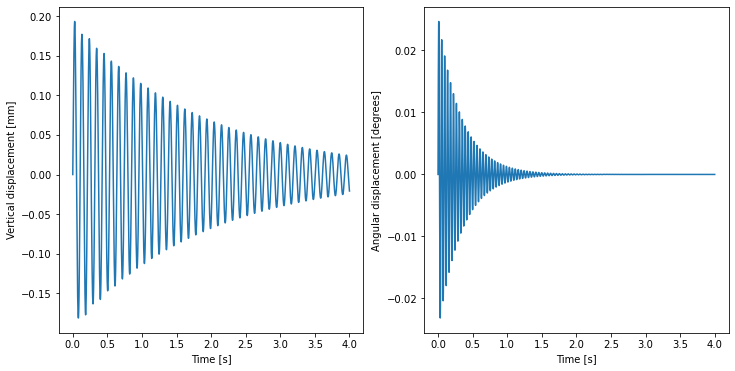

In [20]:
steps = int(1e4)
q = 0.5 * rhoair * V ** 2
cg = cog * MAC
ac *= MAC
C1 = 3 # Fixed support
M = massperlength * (b/2 - z)
S = S1 / 2 # Half wing area
Iz = (M / 6) * wingboxb * wingboxh # https://www.piping-designer.com/index.php/mathematics/geometry/plane-geometry/2342-thin-wall-rectangle
ka, kh = 2 * GJ / z, C1 * EI / (z / 2) ** 3
Dh = 0.02 * 2 * np.sqrt(ka * M) # https://www.sciencedirect.com/science/article/pii/S1877705816302284
Da = 0.02 * 2 * np.sqrt(Iz * ka)
dT = distanceT * MAC
force = np.concatenate([np.array([[(q / V) * Cla * S * u, (q / V) * Cla * S * u * (cg-ac)]]).T] + \
                       [[[0]*(steps-1), [0]*(steps-1)]], axis=1)

A3 = (1 / M) * np.array([-kh, Cla * q * S, -Dh, 0])
A4 = (1 / Iz) * np.array([0, -ka + Cla * q * S * (cg - ac) * MAC, 0, -Da])

A = np.array([[0, 0, 1, 0],
              [0, 0, 0, 1], A3, A4])
B = np.concatenate([np.zeros((2, 2)), [[1 / M, 0], [0, 1 / Iz]]])
C = np.concatenate([np.identity(4), A[-2:, :], [[0, Cla * q * S, 0, 0]]])
D = np.concatenate([np.zeros((4, 2)), [[1 / M, 0], [0, 1 / Iz]], np.zeros((1, 2))])

sys = ml.ss(A, B, C, D)
T = np.linspace(0, 4, steps)
T, y = c.forced_response(sys, T, U=force)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
sns.lineplot(x=T, y=y[1, :] * 180 / np.pi)
plt.xlabel('Time [s]')
plt.ylabel('Angular displacement [degrees]')
plt.subplot(1, 2, 1)
sns.lineplot(x=T, y=y[0, :]*1e3)
plt.xlabel('Time [s]')
plt.ylabel('Vertical displacement [mm]')
plt.savefig('divergence.jpg')

## Whirl Flutter

In [43]:
from scipy.integrate import quad

In [118]:
V = 5
R = 0.6 / 2
Mprop = 502
Omega = 4000*2*np.pi/60
chord = 0.5 # propeller
a = 2 # Distance to connection (in radii)
Ix, In = 0.5 * Mprop * (R) ** 2 + (a * R) ** 2 * Mprop, 0.5 * Mprop * (R) ** 2 + (a * R) ** 2 * Mprop + 0.25 * Mprop * R ** 2 + Mprop * (a * R) ** 2 / 3
Kth, Kpsi = 1229, 1134
Dth, Dpsi = 0.02 * np.sqrt(Kth * In), 0.02 * np.sqrt(Kpsi * In)
Nb = 5 # Number of blades
rhoair = 0.962870
clalpha = 2 * np.pi # lift curve prop

In [5]:
# R = 0.152 # m
# Omega = 4000 # rad s−1
# V = 6.7 # ms−1
# a = 0.25
# Ix = 0.000103 # kg m2
# In = 0.000178 # kg m2
# Dth	 = 0.001 # Nm s rad−1
# Kth = 0.4 # Nm rad−1
# Dpsi = 0.001 # Nm s rad−1
# Kpsi = 0.4 # Nm rad−1
# Nb = 4
# chord =	0.026 # m
# clalpha = 2*np.pi # rad−1
# rhoair = 0.962870

Text(0, 0.5, 'Pitch displacement [degrees]')

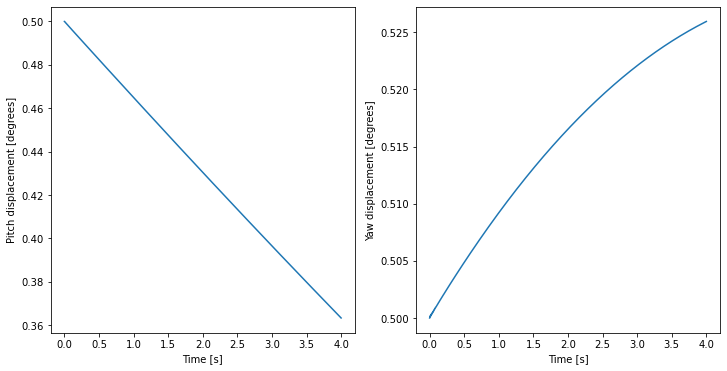

In [119]:
mu = V / (Omega * R)
A1 = (chord / R) * quad(lambda eta: mu * mu / np.sqrt(mu*mu + eta*eta), 0, 1)[0]
A1p = mu * A1
A2p = (chord / R) * quad(lambda eta: mu * mu * eta*eta / np.sqrt(mu*mu + eta*eta), 0, 1)[0]
A3 = (chord / R) * quad(lambda eta: eta*eta / np.sqrt(mu*mu + eta*eta), 0, 1)[0]

Ka = 0.5 * rhoair * clalpha * R ** 4 * Omega * Omega
A34 = Nb * 0.5 * Ka * R * np.array([[a*A1p, -A2p, -(A3+a*a*A1)/Omega, 0],
                                   [A2p, a*A1p, 0, -(A3 + a*a*A1)/Omega]])

M = np.array([[In, 0], [0, In]])
K = np.array([[Kth, 0], [0, Kpsi]])
D = np.array([[Dth, -Ix * Omega], [Ix * Omega, Dpsi]])

J = np.concatenate([np.concatenate([np.zeros((2, 2)), np.identity(2)], axis=1),
                   np.concatenate([-np.linalg.inv(M) @ K, -np.linalg.inv(M) @ D], axis=1)])

A = np.concatenate([J[:2, :], A34 - J[2:, :]])
B = np.concatenate([np.zeros((2, 2)), -np.linalg.inv(M)])
C = np.concatenate([np.identity(4), A[-2:]])
D = np.concatenate([np.zeros((2, 2)), B])
sys = ml.ss(A, B, C, D)
t, y = c.forced_response(sys, T=np.linspace(0, 8, 10000), U=0, X0=np.array([[np.pi/180/2,  np.pi/180/2] + [0]*2]).T)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
sns.lineplot(x=T, y=y[1, :] * 180 / np.pi)
plt.xlabel('Time [s]')
plt.ylabel('Yaw displacement [degrees]')
plt.subplot(1, 2, 1)
sns.lineplot(x=T, y=y[0, :]* 180 / np.pi)
plt.xlabel('Time [s]')
plt.ylabel('Pitch displacement [degrees]')
# plt.savefig('whirl2.jpg')

In [7]:
vals, vex = np.linalg.eigh(sys.A)
D = np.array([[Dth, -Ix * Omega], [Ix * Omega, Dpsi]])
np.linalg.eigh(D)[0]

array([-0.411,  0.413])